In [56]:
# Imports
from itertools import pairwise
import pickle
import networkx as nx
from a_star import A_star
from utils.fret_calculations import build_fret_graph

In [57]:
# Load in spectral data for natural chlorophylls in Et20 solvent
et20_spectra = pickle.load(open('./data/et20_spectra.pkl', 'rb'))
et20_molecules = list(et20_spectra.keys())
et20_graph = build_fret_graph(et20_molecules, et20_spectra);

1754754907.0055676 2.555407141095408
11492646321.657314 1.0343830164606473
18673752307.16014 0.7495404538199352
994388176.9774041 3.0891329788524713
17714606867.4449 0.7776969150417754
16743542367.426754 0.8085647431355256
36501314721.81208 0.45168041397148323
55256942231.93328 0.32001960389334416
53125315597.306465 0.33094837045002923
45024707454.44319 0.38039771709141906
52254280625.59186 0.33563404057674223
25757064516.102287 0.5928375956302053
18212795936.784164 0.7628007780051238
1090507172.8504953 3.0012549048971153
16228081253.953297 0.8260244035601969
21906952808.127216 0.668503646204537
14517662523.887724 0.890160964063976
1200046316.8065314 2.9105199375118964
12135275699.36684 0.9996542038598695
6025639578.795559 1.4948400946002172
48432153852.367905 0.3578851230159029
21320617324.88329 0.6818219277165671
21970645009.540684 0.6670893266092586
53487649004.8277 0.32903787709774857
18299291561.294495 0.7602752172612376
37721888839.53235 0.4398507448288501
10587139883.449179 1.08

/Users/cole/Documents/msse/fall_2025/chem-274B/micropresentation-group/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/cole/Documents/msse/fall_2025/chem-274B/micropresentation-group/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [58]:
source = 'CHL030_Ch f'
target = 'CHL006_Chl a'
heuristic = lambda p, n: 0 # Set heuristic to return 0 - reduces to dijkstra's
chlf_chla_path = A_star(et20_graph, source, target, heuristic)
chlf_chla_path

['CHL030_Ch f', 'CHL021_Chl d', 'CHL006_Chl a']

In [59]:
chl_keys = {'CHL070_Chl b2':'Chl B2', 'CHL215_Chl c':'Chl C', 'CHL205_BChl f [E,M]':'BChl F',
'CHL014_Chl b':'Chl B', 'CHL249_ProtoPhe a':'Phe A', 'CHL273_BPhe a':'BPhe A', 'CHL047_Phe b':'Phe B',
'CHL021_Chl d':'Chl D', 'CHL064_Chl a2':'Chl A2', 'CHL006_Chl a':'Chl A', 'CHL030_Ch f':'Chl F',
'CHL197_BChl d [E,E]+[P,M]':'BChl D', 'CHL052_Phe d':'Phe D', 'CHL202_BChl e [E,E]+[P,E]':'BChl E', 
'CHL231_Phe c':'Phe C'}
pos = nx.spring_layout(et20_graph)

In [60]:
max_weight = max([weight for _, _, weight in et20_graph.edges(data='weight')])

In [61]:
path_edgelist = [pair for pair in pairwise(chlf_chla_path)]

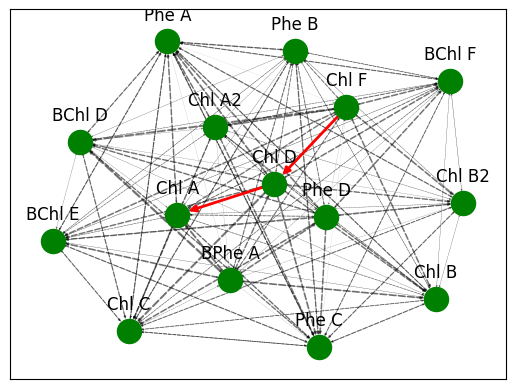

In [62]:
nx.draw_networkx_edges(
   et20_graph,
   pos=pos, alpha=0.5,
   style="dashed",arrowsize=3,
   width = [0.3*w for _, _, w in et20_graph.edges.data('weight')]
);

nx.draw_networkx_edges(
   et20_graph, width=2,
   pos=pos, alpha=1,
   edge_color='r',
   edgelist=path_edgelist
);

nx.draw_networkx_nodes(
   et20_graph,
   pos=pos,
   node_color='g',
);

nx.draw_networkx_labels(
   et20_graph, pos={k: (v[0], v[1]+0.15) for k,v in pos.items()},
   labels=chl_keys,
   font_size=12, font_family="sans-serif"
);